In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set(style="whitegrid")

In [2]:
df = pd.read_excel("data.xlsx")

# Rename columns for easier coding
df.columns = [
    "Trt","Rep","Color","Aroma",
    "External_Texture",
    "Internal_Texture_Structure",
    "Internal_Texture_Mouthfeel",
    "Taste","Aftertaste","General_Acceptability"
]

In [3]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==============================
# 4. Fill Missing Values
# ==============================

df = df.groupby("Trt").apply(lambda x: x.fillna(x.mean()))
df = df.reset_index(drop=True)

print("Missing values after cleaning:")
print(df.isna().sum())

Missing values after cleaning:
Trt                           0
Rep                           0
Color                         0
Aroma                         0
External_Texture              0
Internal_Texture_Structure    0
Internal_Texture_Mouthfeel    0
Taste                         0
Aftertaste                    0
General_Acceptability         0
dtype: int64


/tmp/ipykernel_242/1377887141.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Trt").apply(lambda x: x.fillna(x.mean()))


In [4]:
attributes = [
    "Color","Aroma","External_Texture",
    "Internal_Texture_Structure",
    "Internal_Texture_Mouthfeel",
    "Taste","Aftertaste","General_Acceptability"
]

mean_scores = df.groupby("Trt")[attributes].mean()
std_scores = df.groupby("Trt")[attributes].std()

summary_table = mean_scores.round(2).astype(str) + " ± " + std_scores.round(2).astype(str)

print("\nSummary Table:")
print(summary_table)

summary_table.to_csv("sensory_summary_table.csv")


Summary Table:
           Color        Aroma External_Texture Internal_Texture_Structure  \
Trt                                                                         
0    7.22 ± 1.58  6.98 ± 1.31      6.57 ± 1.47                6.91 ± 1.36   
1    6.19 ± 1.64  6.24 ± 1.52        6.0 ± 1.4                6.22 ± 1.53   
2    6.46 ± 1.66  6.66 ± 1.64      6.37 ± 1.29                6.48 ± 1.57   
3     6.3 ± 1.43   6.56 ± 1.3      6.24 ± 1.37                6.27 ± 1.53   

    Internal_Texture_Mouthfeel        Taste   Aftertaste General_Acceptability  
Trt                                                                             
0                  6.98 ± 1.34  7.04 ± 1.44  6.84 ± 1.41             7.4 ± 1.0  
1                  6.44 ± 1.44  6.31 ± 1.61  6.09 ± 1.69            6.31 ± 1.5  
2                  6.39 ± 1.67  6.38 ± 1.67    6.2 ± 1.8           6.62 ± 1.46  
3                   6.5 ± 1.67   6.42 ± 1.7  6.23 ± 1.64            6.6 ± 1.23  


In [5]:
for attr in attributes:

    model = ols(f'{attr} ~ C(Trt)', data=df).fit()
    anova = sm.stats.anova_lm(model, typ=2)

    print(f"\nANOVA for {attr}")
    print(anova)


ANOVA for Color
              sum_sq     df         F    PR(>F)
C(Trt)     58.808333    3.0  7.853759  0.000043
Residual  888.566667  356.0       NaN       NaN

ANOVA for Aroma
              sum_sq     df         F    PR(>F)
C(Trt)     24.652778    3.0  3.905188  0.009124
Residual  749.122222  356.0       NaN       NaN

ANOVA for External_Texture
              sum_sq     df         F    PR(>F)
C(Trt)     15.166667    3.0  2.640433  0.049317
Residual  681.622222  356.0       NaN       NaN

ANOVA for Internal_Texture_Structure
              sum_sq     df         F    PR(>F)
C(Trt)     26.684555    3.0  3.953801  0.008546
Residual  800.892010  356.0       NaN       NaN

ANOVA for Internal_Texture_Mouthfeel
              sum_sq     df         F    PR(>F)
C(Trt)     19.737582    3.0  2.781483  0.040938
Residual  842.066167  356.0       NaN       NaN

ANOVA for Taste
              sum_sq     df         F    PR(>F)
C(Trt)     31.233333    3.0  4.036447  0.007646
Residual  918.222222  356.0  

In [6]:
for attr in attributes:

    print(f"\nTukey HSD for {attr}")

    tukey = pairwise_tukeyhsd(
        endog=df[attr],
        groups=df["Trt"],
        alpha=0.05
    )

    print(tukey)


Tukey HSD for Color
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -1.0333 0.0001 -1.6412 -0.4254   True
     0      2  -0.7667 0.0068 -1.3746 -0.1588   True
     0      3  -0.9222 0.0006 -1.5301 -0.3143   True
     1      2   0.2667 0.6698 -0.3412  0.8746  False
     1      3   0.1111 0.9652 -0.4968   0.719  False
     2      3  -0.1556 0.9118 -0.7635  0.4524  False
----------------------------------------------------

Tukey HSD for Aroma
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -0.7333 0.0043 -1.2915 -0.1752   True
     0      2  -0.3222 0.4446 -0.8804  0.2359  False
     0      3  -0.4222 0.2082 -0.9804  0.1359  False
     1      2   0.4111 0.2294 -0.1471  0.9693  False
     1      3   0.3111  0.476 -0.2471  0.8693  False
    

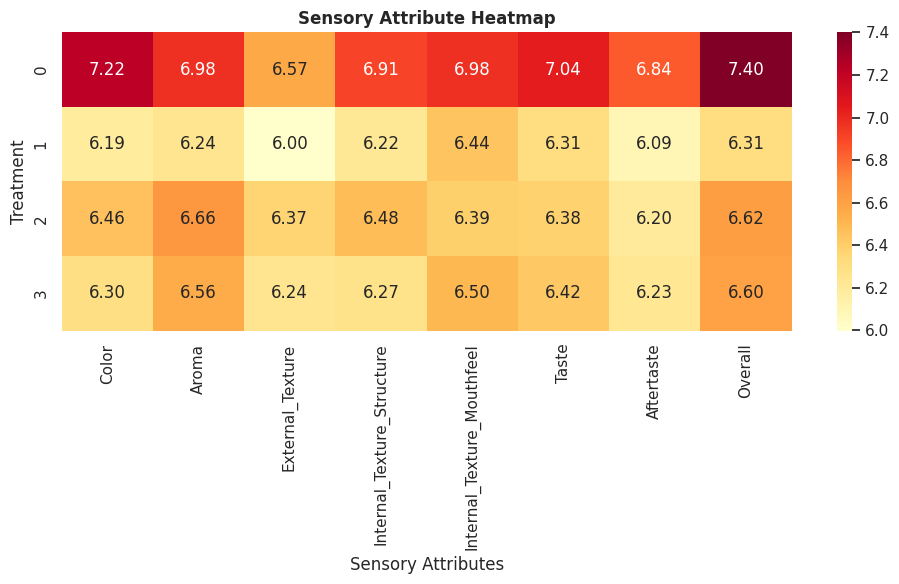

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    mean_scores,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Sensory Attribute Heatmap", fontweight='bold')
plt.xlabel("Sensory Attributes")
plt.ylabel("Treatment")

plt.tight_layout()
plt.savefig("sensory_heatmap.png")
plt.show()

/tmp/ipykernel_209/3099313265.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


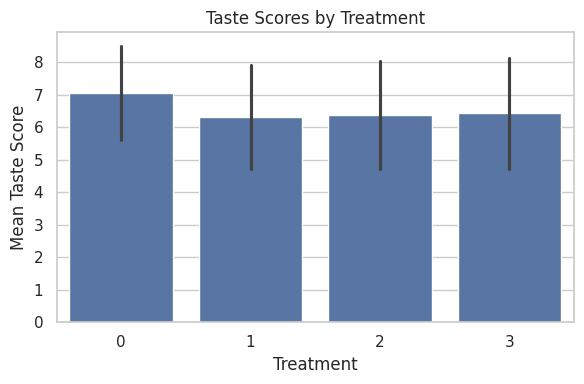

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Trt",
    y="Taste",
    data=df,
    ci="sd"
)

plt.title("Taste Scores by Treatment")
plt.ylabel("Mean Taste Score")
plt.xlabel("Treatment")

plt.tight_layout()
plt.savefig("taste_bargraph.png")
plt.show()


/tmp/ipykernel_209/3130032331.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


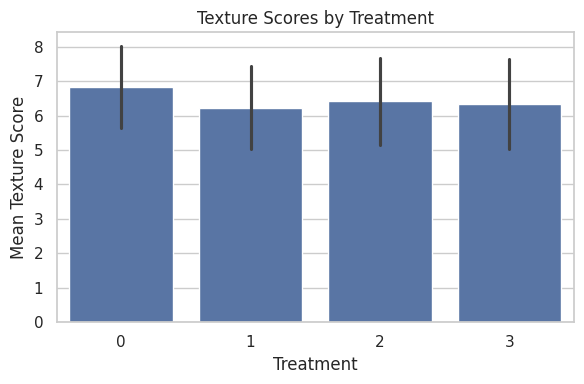

In [ ]:
df["Texture"] = (
    df["External_Texture"] +
    df["Internal_Texture_Structure"] +
    df["Internal_Texture_Mouthfeel"]
) / 3

plt.figure(figsize=(6,4))

sns.barplot(
    x="Trt",
    y="Texture",
    data=df,
    ci="sd"
)

plt.title("Texture Scores by Treatment")
plt.ylabel("Mean Texture Score")
plt.xlabel("Treatment")

plt.tight_layout()
plt.savefig("texture_bargraph.png")
plt.show()


/tmp/ipykernel_209/1129058683.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


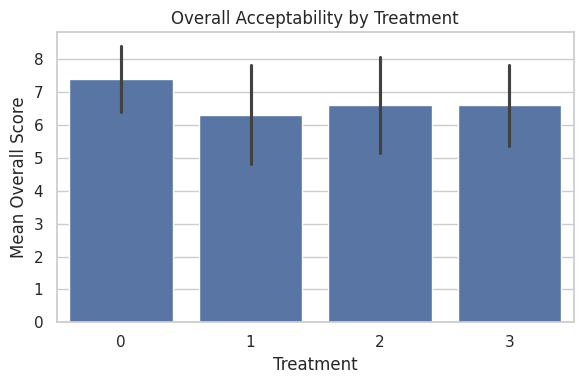

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Trt",
    y="General_Acceptability",
    data=df,
    ci="sd"
)

plt.title("General Acceptability by Treatment")
plt.ylabel("Mean General Acceptability Score")
plt.xlabel("Treatment")

plt.tight_layout()
plt.savefig("overall_bargraph.png")
plt.show()

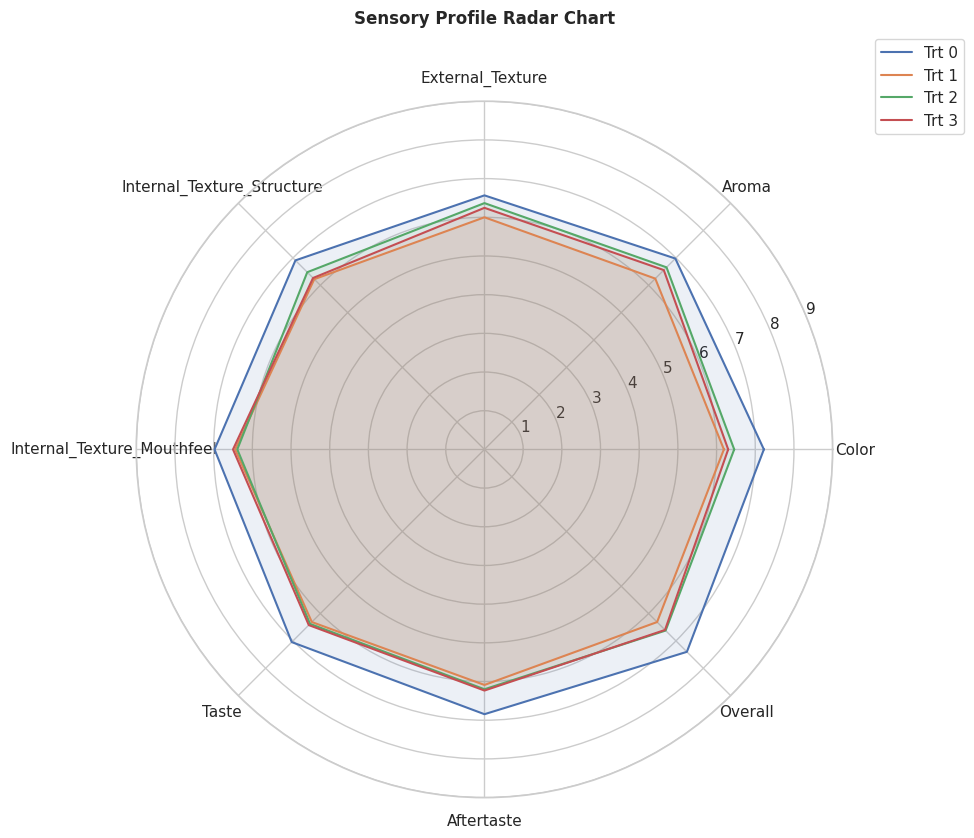


Analysis Complete!


In [ ]:
labels = attributes
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

for i, row in mean_scores.iterrows():

    values = row.values
    values = np.concatenate((values,[values[0]]))
    angle_plot = np.concatenate((angles,[angles[0]]))

    ax.plot(angle_plot, values, label=f"Trt {i}")
    ax.fill(angle_plot, values, alpha=0.1)

ax.set_thetagrids(angles * 180/np.pi, labels)
ax.set_ylim(0, 9) # Set the maximum radius to 9

plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.title("Sensory Profile Radar Chart", y=1.1, ) # Adjust title position

plt.tight_layout()
plt.savefig("sensory_radar_chart.png")
plt.show()

print("\nAnalysis Complete!")

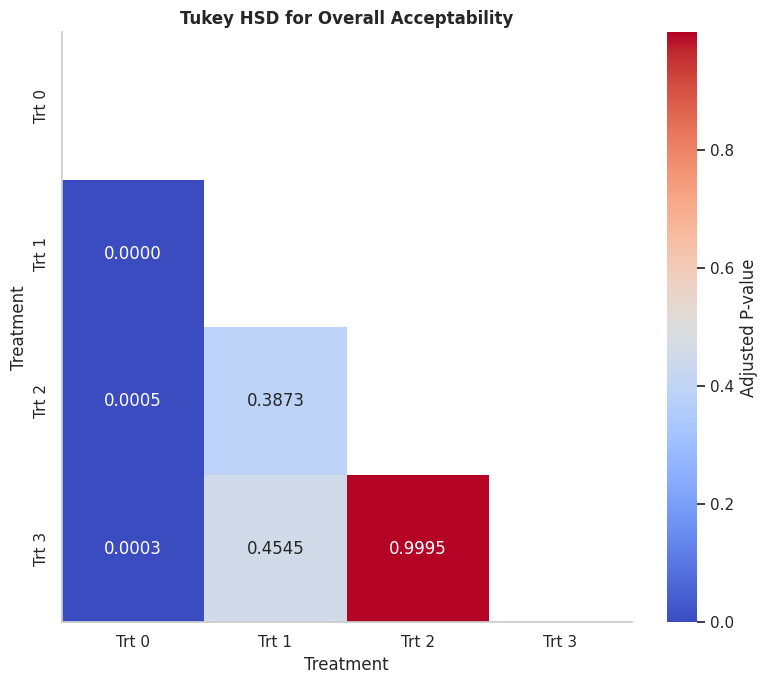

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Re-run Tukey HSD specifically for the 'General_Acceptability' attribute
tukey_overall = pairwise_tukeyhsd(
    endog=df["General_Acceptability"],
    groups=df["Trt"],
    alpha=0.05
)

# Convert the Tukey HSD summary into a DataFrame
tukey_df = pd.DataFrame(data=tukey_overall._results_table.data[1:], columns=tukey_overall._results_table.data[0])

# Get the number of unique treatments
num_groups = df['Trt'].nunique()

# Create a matrix to store p-adjusted values for the heatmap
tukey_matrix_p_adj = pd.DataFrame(np.nan, index=range(num_groups), columns=range(num_groups))

# Fill the matrix with p-adjusted values
for index, row in tukey_df.iterrows():
    g1 = int(row['group1'])
    g2 = int(row['group2'])
    tukey_matrix_p_adj.loc[g1, g2] = row['p-adj']
    tukey_matrix_p_adj.loc[g2, g1] = row['p-adj'] # Symmetric

# For the diagonal (comparison of a group with itself), p-value is 1 (no difference)
for i in range(num_groups):
    tukey_matrix_p_adj.loc[i, i] = 1.0

# Create a mask for the upper triangle and the diagonal
mask = np.triu(np.ones_like(tukey_matrix_p_adj, dtype=bool), k=0)

# Plot the heatmap
plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    tukey_matrix_p_adj,
    annot=True,
    cmap='coolwarm',
    fmt='.4f',
    linewidths=0, # Removed borders between cells
    linecolor='black',
    cbar_kws={'label': 'Adjusted P-value'},
    xticklabels=[f'Trt {i}' for i in range(num_groups)],
    yticklabels=[f'Trt {i}' for i in range(num_groups)],
    mask=mask # Apply the mask
)

ax.grid(False) # Ensure background gridlines are removed
sns.despine(ax=ax) # Apply despine

plt.title('Tukey HSD for General Acceptability', fontweight='bold')
plt.xlabel('Treatment')
plt.ylabel('Treatment')
plt.tight_layout()
plt.savefig('tukey_hsd_overall_heatmap_p_adj_strictly_lower_triangle.png')
plt.show()

In [ ]:
# Install xlsxwriter if it's not already installed
!pip install xlsxwriter

import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Assuming 'df' is already defined in the environment
# Corrected attributes list to match actual DataFrame columns
attributes = [
    "Color","Aroma","External_Texture",
    "Internal_Texture_Softness", # Corrected from Internal_Texture_Structure
    "Internal_Texture_Moisture", # Corrected from Internal_Texture_Mouthfeel
    "Taste","Aftertaste","General_Acceptability"
]

tukey_results_dfs = {}

for attr in attributes:
    # Perform Tukey HSD test
    tukey_hsd_result = pairwise_tukeyhsd(
        endog=df[attr],
        groups=df["Trt"],
        alpha=0.05
    )

    # Convert the summary table to a pandas DataFrame
    tukey_df = pd.DataFrame(
        data=tukey_hsd_result._results_table.data[1:],
        columns=tukey_hsd_result._results_table.data[0]
    )
    tukey_results_dfs[attr] = tukey_df

# Define the output Excel file name
output_excel_file = "tukey_hsd_all_attributes.xlsx"

# Create a Pandas Excel writer using XlsxWriter as the engine.
# This allows saving multiple DataFrames to different sheets.
with pd.ExcelWriter(output_excel_file, engine='xlsxwriter') as writer:
    for attr_name, result_df in tukey_results_dfs.items():
        # Write each DataFrame to a different worksheet
        # Replace characters that are not allowed in Excel sheet names if necessary
        sheet_name = attr_name.replace('/', '_').replace('\\', '_')
        result_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Tukey HSD results for all attributes saved to {output_excel_file}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.2 MB/s eta 0:00:00
Tukey HSD results for all attributes saved to tukey_hsd_all_attributes.xlsx
